# HW10-11

Сделал две части:
- Часть A: классификация на `CIFAR100` (`C1-C4`).
- Часть B: сегментация на `OxfordIIITPet` (`V1-V2`).

Все артефакты сохраняются в `./artifacts/`. Ноутбук запускается сверху вниз.


In [1]:
from pathlib import Path
import json
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR100, OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights


print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)


torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if Path.cwd().name == "HW10-11":
    ROOT = Path.cwd()
else:
    ROOT = Path("homeworks") / "HW10-11"

ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = ROOT / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


FAST_MODE = True
print("FAST_MODE =", FAST_MODE)


Device: cpu
FAST_MODE = True


In [ ]:
# Part A: CIFAR100 data and transforms 
base_transform_cnn = transforms.Compose([
    transforms.ToTensor(),
])

aug_transform_cnn = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

resnet_weights = None
try:
    resnet_weights = ResNet18_Weights.DEFAULT
except Exception:
    resnet_weights = None

if resnet_weights is not None:
    transform_resnet = resnet_weights.transforms()
else:
    transform_resnet = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

trainval_base = CIFAR100(root=DATA_DIR, train=True, download=True, transform=base_transform_cnn)
test_base = CIFAR100(root=DATA_DIR, train=False, download=True, transform=base_transform_cnn)

val_size = int(0.2 * len(trainval_base))
train_size = len(trainval_base) - val_size
split_generator = torch.Generator().manual_seed(SEED)
train_base, val_base = random_split(trainval_base, [train_size, val_size], generator=split_generator)

if FAST_MODE:
    train_base = Subset(train_base, range(min(8000, len(train_base))))
    val_base = Subset(val_base, range(min(2000, len(val_base))))
    test_base = Subset(test_base, range(min(2000, len(test_base))))

batch_size = 128 if device.type == "cuda" else 64

loader_train_base = DataLoader(train_base, batch_size=batch_size, shuffle=True, num_workers=0)
loader_val_base = DataLoader(val_base, batch_size=batch_size, shuffle=False, num_workers=0)
loader_test_base = DataLoader(test_base, batch_size=batch_size, shuffle=False, num_workers=0)

x_batch, y_batch = next(iter(loader_train_base))
print("Part A batch x.shape:", tuple(x_batch.shape), "y.shape:", tuple(y_batch.shape))


C:\Users\Maken\Desktop\AI-course\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Part A batch x.shape: (64, 3, 32, 32) y.shape: (64,)


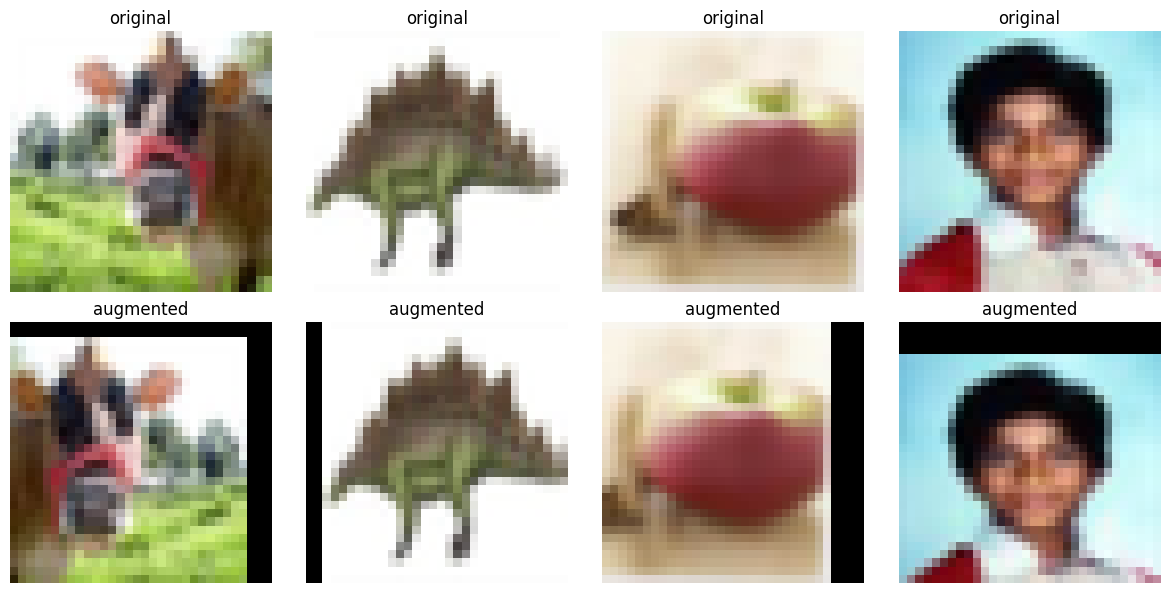

In [ ]:
# Part A: augmentations preview 
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

raw_ds = CIFAR100(root=DATA_DIR, train=True, download=False, transform=None)
for i in range(4):
    img, _ = raw_ds[i]
    axes[0, i].imshow(img)
    axes[0, i].set_title("original")
    axes[0, i].axis("off")

    aug_img = aug_transform_cnn(img).permute(1, 2, 0).numpy()
    axes[1, i].imshow(np.clip(aug_img, 0, 1))
    axes[1, i].set_title("augmented")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=140)
plt.show()


In [ ]:
# Part A: models and training helpers 
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def build_resnet(mode: str, num_classes=100):
    if resnet_weights is not None:
        model = resnet18(weights=resnet_weights)
    else:
        model = resnet18(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if mode == "head-only":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "finetune-layer4-fc":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        raise ValueError("Unknown mode")

    return model


def run_experiment(exp_id, model, train_loader, val_loader, epochs, lr):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
        print(f"{exp_id} | epoch {epoch}/{epochs} | tr_acc={tr_acc:.4f} | va_acc={va_acc:.4f}")

    return {
        "exp_id": exp_id,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_state": best_state,
        "epochs_trained": epochs,
        "lr": lr,
    }


In [ ]:
# Part A: run C1-C4 
trainval_aug = CIFAR100(root=DATA_DIR, train=True, download=False, transform=aug_transform_cnn)
train_aug, val_aug = random_split(
    trainval_aug, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)
if FAST_MODE:
    train_aug = Subset(train_aug, range(min(8000, len(train_aug))))
    val_aug = Subset(val_aug, range(min(2000, len(val_aug))))

loader_train_aug = DataLoader(train_aug, batch_size=batch_size, shuffle=True, num_workers=0)
loader_val_aug = DataLoader(val_aug, batch_size=batch_size, shuffle=False, num_workers=0)

trainval_resnet = CIFAR100(root=DATA_DIR, train=True, download=False, transform=transform_resnet)
test_resnet = CIFAR100(root=DATA_DIR, train=False, download=False, transform=transform_resnet)
train_resnet, val_resnet = random_split(
    trainval_resnet, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)
if FAST_MODE:
    train_resnet = Subset(train_resnet, range(min(8000, len(train_resnet))))
    val_resnet = Subset(val_resnet, range(min(2000, len(val_resnet))))
    test_resnet = Subset(test_resnet, range(min(2000, len(test_resnet))))

loader_train_resnet = DataLoader(train_resnet, batch_size=batch_size, shuffle=True, num_workers=0)
loader_val_resnet = DataLoader(val_resnet, batch_size=batch_size, shuffle=False, num_workers=0)
loader_test_resnet = DataLoader(test_resnet, batch_size=batch_size, shuffle=False, num_workers=0)

epochs_cnn = 2 if FAST_MODE else 8
epochs_resnet = 2 if FAST_MODE else 6
lr_cnn = 1e-3
lr_resnet = 3e-4

results = {}
results["C1"] = run_experiment(
    "C1",
    SimpleCNN(num_classes=100),
    loader_train_base,
    loader_val_base,
    epochs=epochs_cnn,
    lr=lr_cnn,
)
results["C2"] = run_experiment(
    "C2",
    SimpleCNN(num_classes=100),
    loader_train_aug,
    loader_val_aug,
    epochs=epochs_cnn,
    lr=lr_cnn,
)
results["C3"] = run_experiment(
    "C3",
    build_resnet("head-only", num_classes=100),
    loader_train_resnet,
    loader_val_resnet,
    epochs=epochs_resnet,
    lr=lr_resnet,
)
results["C4"] = run_experiment(
    "C4",
    build_resnet("finetune-layer4-fc", num_classes=100),
    loader_train_resnet,
    loader_val_resnet,
    epochs=epochs_resnet,
    lr=lr_resnet,
)

best_exp_id = max(["C1", "C2", "C3", "C4"], key=lambda k: results[k]["best_val_acc"])
print("Best classification experiment:", best_exp_id, "| val_acc =", results[best_exp_id]["best_val_acc"])


C1 | epoch 1/2 | tr_acc=0.0194 | va_acc=0.0325


C1 | epoch 2/2 | tr_acc=0.0393 | va_acc=0.0520


C2 | epoch 1/2 | tr_acc=0.0181 | va_acc=0.0235


C2 | epoch 2/2 | tr_acc=0.0409 | va_acc=0.0520


C3 | epoch 1/2 | tr_acc=0.0699 | va_acc=0.1535


C3 | epoch 2/2 | tr_acc=0.2311 | va_acc=0.2785


C4 | epoch 1/2 | tr_acc=0.3450 | va_acc=0.5045


C4 | epoch 2/2 | tr_acc=0.7359 | va_acc=0.5600
Best classification experiment: C4 | val_acc = 0.56


Best model test_accuracy: 0.556


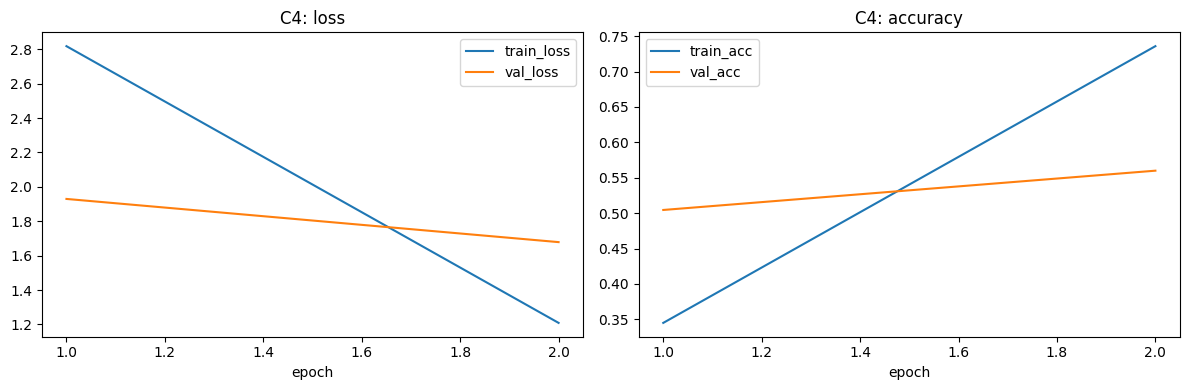

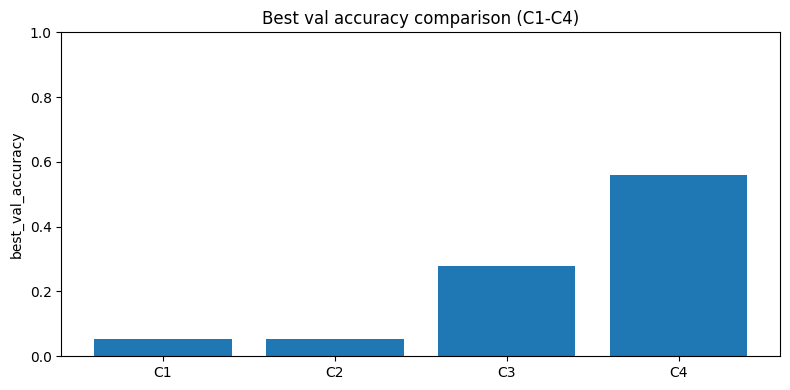

In [ ]:
# Part A: save best classifier + plots 
if best_exp_id in ("C1", "C2"):
    best_model = SimpleCNN(num_classes=100)
    best_test_loader = loader_test_base
    model_summary = "SimpleCNN"
    train_transform_name = "base" if best_exp_id == "C1" else "augmented"
else:
    mode = "head-only" if best_exp_id == "C3" else "finetune-layer4-fc"
    best_model = build_resnet(mode, num_classes=100)
    best_test_loader = loader_test_resnet
    model_summary = f"ResNet18-{mode}"
    train_transform_name = "resnet_preprocess"

best_model.load_state_dict(results[best_exp_id]["best_state"])
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, best_test_loader, criterion, device)
print("Best model test_accuracy:", round(test_acc, 4))

torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_classifier.pt")

best_config = {
    "dataset": "CIFAR100",
    "seed": SEED,
    "best_experiment_id": best_exp_id,
    "model_summary": model_summary,
    "train_transform": train_transform_name,
    "optimizer": "Adam",
    "lr": float(results[best_exp_id]["lr"]),
    "epochs_trained": int(results[best_exp_id]["epochs_trained"]),
    "best_val_accuracy": float(results[best_exp_id]["best_val_acc"]),
    "test_accuracy": float(test_acc),
    "fast_mode": FAST_MODE,
}
with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

# Curves for best run
hist_best = results[best_exp_id]["history"]
epochs_axis = np.arange(1, len(hist_best["train_loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs_axis, hist_best["train_loss"], label="train_loss")
ax[0].plot(epochs_axis, hist_best["val_loss"], label="val_loss")
ax[0].set_title(f"{best_exp_id}: loss")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(epochs_axis, hist_best["train_acc"], label="train_acc")
ax[1].plot(epochs_axis, hist_best["val_acc"], label="val_acc")
ax[1].set_title(f"{best_exp_id}: accuracy")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=140)
plt.show()

# Comparison C1-C4
ids = ["C1", "C2", "C3", "C4"]
vals = [results[i]["best_val_acc"] for i in ids]
plt.figure(figsize=(8, 4))
plt.bar(ids, vals)
plt.ylim(0, 1)
plt.title("Best val accuracy comparison (C1-C4)")
plt.ylabel("best_val_accuracy")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=140)
plt.show()


In [ ]:
# Part B: OxfordIIITPet segmentation setup 
class PetSegDataset(torch.utils.data.Dataset):
    def __init__(self, split="trainval", image_size=256):
        self.ds = OxfordIIITPet(
            root=DATA_DIR,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.image_size = image_size
        self.img_tf = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, mask = self.ds[idx]
        image = self.img_tf(image)
        mask = transforms.functional.resize(
            mask, (self.image_size, self.image_size), interpolation=transforms.InterpolationMode.NEAREST
        )
        mask = torch.as_tensor(np.array(mask), dtype=torch.int64)
        # In trimap: 1 = pet, 2 = background, 3 = border.
        gt_fg = (mask == 1).to(torch.int64)
        return image, gt_fg


seg_trainval = PetSegDataset(split="trainval", image_size=256)
seg_test = PetSegDataset(split="test", image_size=256)

if FAST_MODE:
    seg_test = Subset(seg_test, range(min(60, len(seg_test))))

seg_loader = DataLoader(seg_test, batch_size=4, shuffle=False, num_workers=0)
xb, yb = next(iter(seg_loader))
print("Part B batch x.shape:", tuple(xb.shape), "y.shape:", tuple(yb.shape))

seg_weights = None
try:
    seg_weights = FCN_ResNet50_Weights.DEFAULT
except Exception:
    seg_weights = None

if seg_weights is not None:
    seg_model = fcn_resnet50(weights=seg_weights).to(device).eval()
else:
    seg_model = fcn_resnet50(weights=None).to(device).eval()


Part B batch x.shape: (4, 3, 256, 256) y.shape: (4, 256, 256)


In [ ]:
# Part B: metrics, postprocessing, V1/V2 
def postprocess_v1(logits):
    probs = torch.softmax(logits, dim=1)
    fg_prob = 1.0 - probs[:, 0]
    return (fg_prob >= 0.5).to(torch.int64)


def postprocess_v2(logits):
    probs = torch.softmax(logits, dim=1)
    fg_prob = 1.0 - probs[:, 0]
    raw_mask = (fg_prob >= 0.7).float().unsqueeze(1)
    smooth = F.avg_pool2d(raw_mask, kernel_size=5, stride=1, padding=2).squeeze(1)
    return (smooth >= 0.5).to(torch.int64)


def iou_binary(pred, target, eps=1e-8):
    inter = ((pred == 1) & (target == 1)).sum().item()
    union = ((pred == 1) | (target == 1)).sum().item()
    if union == 0:
        return 1.0
    return inter / (union + eps)


def precision_recall_binary(pred, target, eps=1e-8):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fp = ((pred == 1) & (target == 0)).sum().item()
    fn = ((pred == 0) & (target == 1)).sum().item()
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return precision, recall


@torch.no_grad()
def evaluate_segmentation(model, loader, postprocess_fn):
    all_iou = []
    all_precision = []
    all_recall = []
    examples = []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)["out"]
        pred = postprocess_fn(logits).cpu()

        for i in range(pred.shape[0]):
            p = pred[i]
            t = y[i]
            all_iou.append(iou_binary(p, t))
            pr, rc = precision_recall_binary(p, t)
            all_precision.append(pr)
            all_recall.append(rc)
            if len(examples) < 4:
                examples.append((x[i].cpu(), t, p))

    return {
        "mean_iou": float(np.mean(all_iou)),
        "pixel_precision": float(np.mean(all_precision)),
        "pixel_recall": float(np.mean(all_recall)),
        "examples": examples,
    }


metrics_v1 = evaluate_segmentation(seg_model, seg_loader, postprocess_v1)
metrics_v2 = evaluate_segmentation(seg_model, seg_loader, postprocess_v2)

print("V1:", metrics_v1["mean_iou"], metrics_v1["pixel_precision"], metrics_v1["pixel_recall"])
print("V2:", metrics_v2["mean_iou"], metrics_v2["pixel_precision"], metrics_v2["pixel_recall"])


V1: 0.6995913065709684 0.7588322068832783 0.882998155205287
V2: 0.7068954641165573 0.8295283787871425 0.8238875501093488


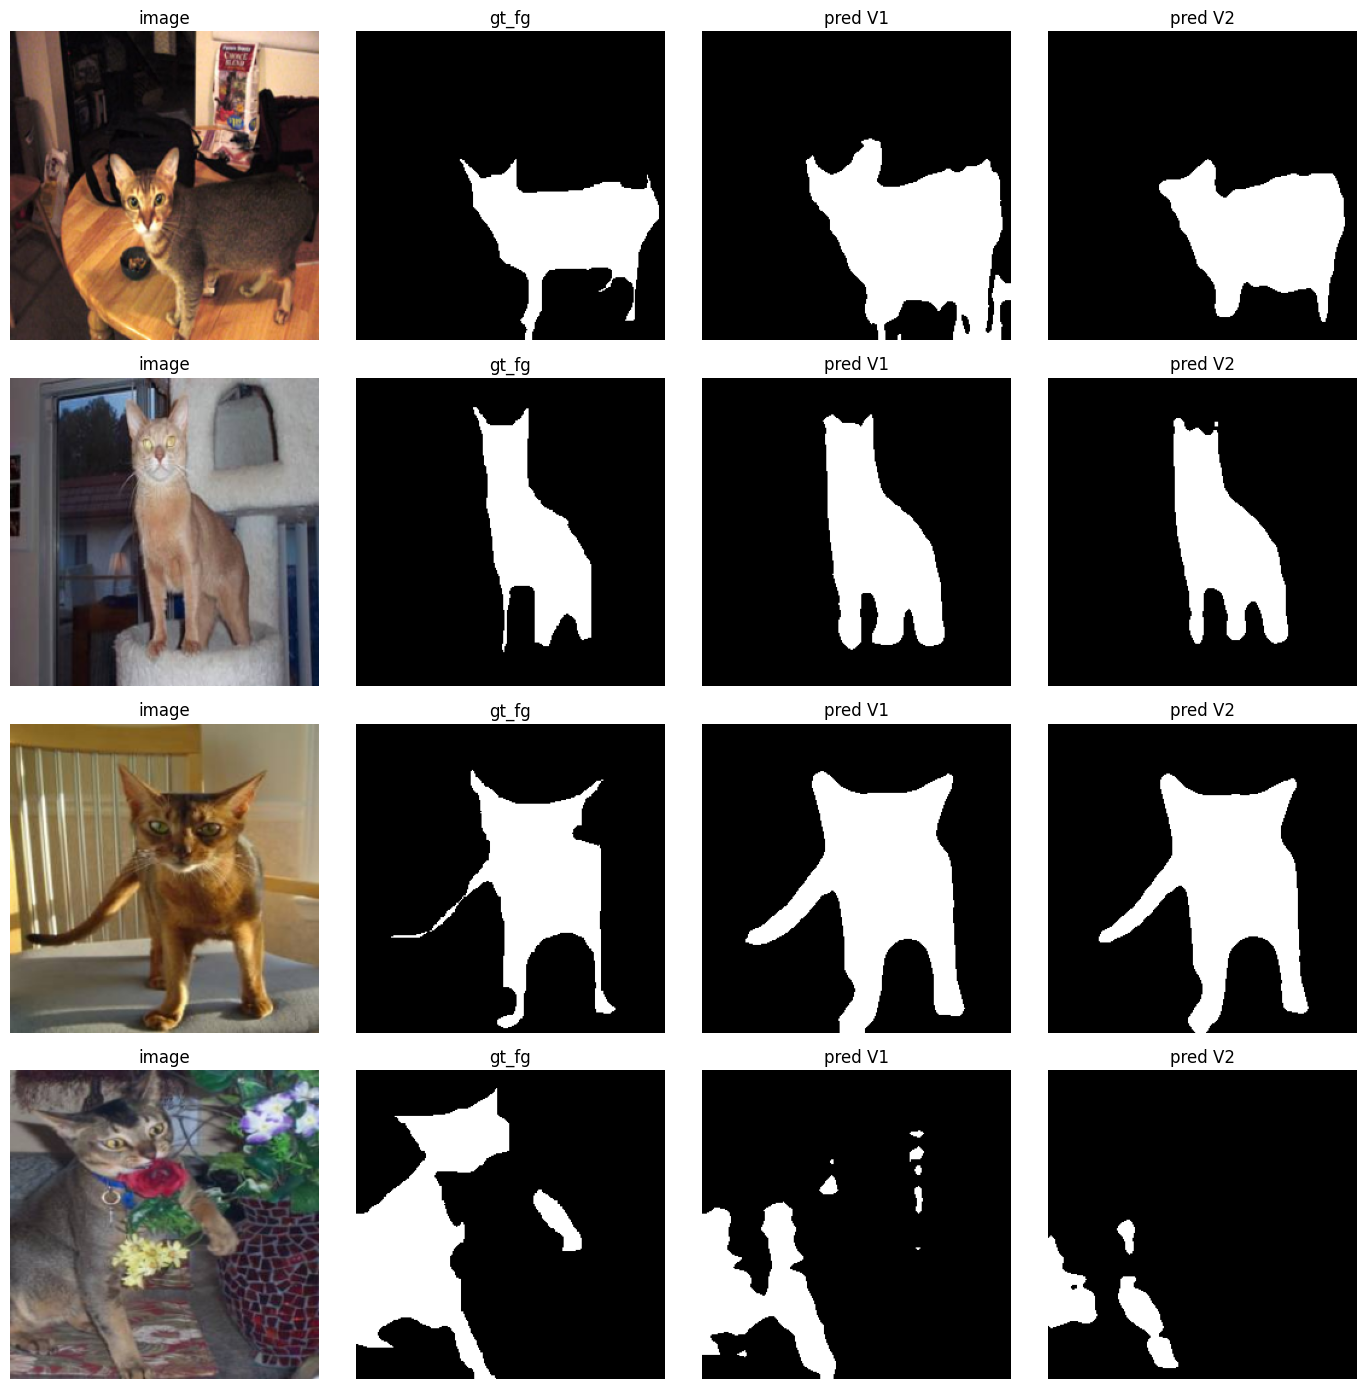

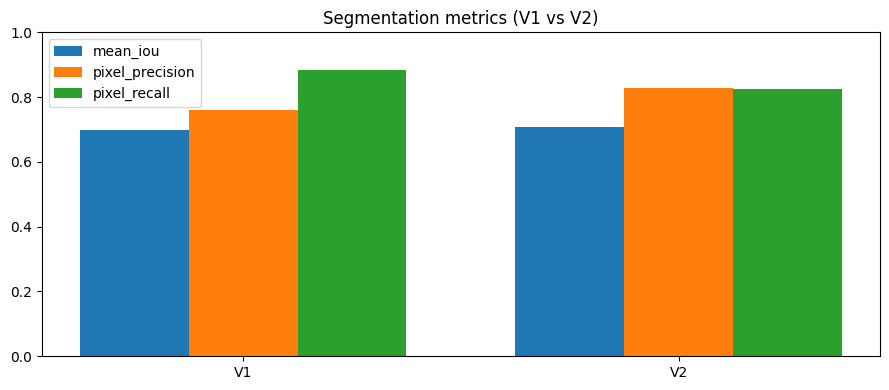

In [ ]:
# Part B: visualizations 
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for row in range(4):
    img, gt, pred_v1 = metrics_v1["examples"][row]
    _, _, pred_v2 = metrics_v2["examples"][row]

    img_np = np.transpose(img.numpy(), (1, 2, 0))
    axes[row, 0].imshow(np.clip(img_np, 0, 1))
    axes[row, 0].set_title("image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt.numpy(), cmap="gray")
    axes[row, 1].set_title("gt_fg")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_v1.numpy(), cmap="gray")
    axes[row, 2].set_title("pred V1")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(pred_v2.numpy(), cmap="gray")
    axes[row, 3].set_title("pred V2")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=140)
plt.show()

labels = ["V1", "V2"]
miou_vals = [metrics_v1["mean_iou"], metrics_v2["mean_iou"]]
prec_vals = [metrics_v1["pixel_precision"], metrics_v2["pixel_precision"]]
rec_vals = [metrics_v1["pixel_recall"], metrics_v2["pixel_recall"]]

x = np.arange(len(labels))
w = 0.25
plt.figure(figsize=(9, 4))
plt.bar(x - w, miou_vals, width=w, label="mean_iou")
plt.bar(x, prec_vals, width=w, label="pixel_precision")
plt.bar(x + w, rec_vals, width=w, label="pixel_recall")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Segmentation metrics (V1 vs V2)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=140)
plt.show()


In [ ]:
# Save runs.csv 
runs_columns = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

rows = []
for exp_id in ["C1", "C2", "C3", "C4"]:
    row = {
        "experiment_id": exp_id,
        "task": "classification",
        "dataset": "CIFAR100",
        "seed": SEED,
        "model_summary": (
            "SimpleCNN" if exp_id in ("C1", "C2")
            else ("ResNet18-head-only" if exp_id == "C3" else "ResNet18-finetune-layer4-fc")
        ),
        "optimizer": "Adam",
        "lr": results[exp_id]["lr"],
        "epochs_trained": results[exp_id]["epochs_trained"],
        "best_val_accuracy": results[exp_id]["best_val_acc"],
        "test_accuracy": test_acc if exp_id == best_exp_id else np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "C2 uses augmentation" if exp_id == "C2" else "",
    }
    rows.append(row)

rows.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "FCN_ResNet50(pretrained)",
    "optimizer": "",
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": metrics_v1["pixel_precision"],
    "recall": metrics_v1["pixel_recall"],
    "mean_iou": metrics_v1["mean_iou"],
    "notes": "foreground = (class != background), thr=0.5",
})
rows.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "FCN_ResNet50(pretrained)",
    "optimizer": "",
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": metrics_v2["pixel_precision"],
    "recall": metrics_v2["pixel_recall"],
    "mean_iou": metrics_v2["mean_iou"],
    "notes": "foreground = (class != background), thr=0.7 + smoothing",
})

runs_df = pd.DataFrame(rows, columns=runs_columns)
runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
runs_df


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,2,0.0520,NaN,NaN,NaN,NaN,
1,C2,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,2,0.0520,NaN,NaN,NaN,NaN,C2 uses augmentation
2,C3,classification,CIFAR100,42,ResNet18-head-only,Adam,0.0003,2,0.2785,NaN,NaN,NaN,NaN,
3,C4,classification,CIFAR100,42,ResNet18-finetune-layer4-fc,Adam,0.0003,2,0.5600,0.556,NaN,NaN,NaN,
4,V1,segmentation,OxfordIIITPet,42,FCN_ResNet50(pretrained),,NaN,0,NaN,NaN,0.758832,0.882998,0.699591,"foreground = (class != background), thr=0.5"
5,V2,segmentation,OxfordIIITPet,42,FCN_ResNet50(pretrained),,NaN,0,NaN,NaN,0.829528,0.823888,0.706895,"foreground = (class != background), thr=0.7 + ..."
